# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** ☐ Standard Analysis ☐ Research-Oriented  
**Group members:**  
- Mads Pagh
- Marcus Mofjeld

**Dataset:**  Spotify Playlists

**Initial task description (Module 1 perspective):**

We propose a project that critiques and expands upon the methodology presented in "Towards a Context-Aware Music
Recommendation Approach: What is Hidden in the Playlist Name?" [CITE]. The original authors demonstrated that
clustering playlist names to infer "listening contexts" can increase recommendation precision by 33% compared to
traditional collaborative filtering. However, their approach relied exclusively on k-means clustering. Our analysis goal
in this first part is Structure Discovery, specifically investigating the intrinsic geometry of these "listening contexts."
As noted in the course material, k-means is a Representative-based algorithm that assumes clusters are spherical,
compact, and distinct. We hypothesize that human-generated musical contexts are likely complex, arbitrary in shape,
and potentially nested, which makes the rigid partitioning of k-means a limitation. To test this, we will compare
the k-means baseline against alternative clustering paradigms: Subspace Clustering and Hierarchical Clustering. By
comparing these techniques, we aim to determine which structural definition best captures the semantic reality of user
playlists.

## 0. Reproducibility and Setup

In [52]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]


## 1. Dataset Description and Loading

### 1.1 Dataset Overview

- Source: https://www.kaggle.com/datasets/andrewmvd/spotify-playlists
- Number of instances: 12,902,045
- Number of features / entities: 4
- Missing values: 0
- Basic statistics:
Unique Users:            15,918
Unique Tracks:           2,036,899
Unique Raw Playlists:    157,530


In [53]:
from preprocessing.preprocessor import load_and_heal_data

# Load dataset (dataframe)
df = load_and_heal_data()

In [54]:
# View the first few rows of the dataframe
df.head()

,user_id,artistname,trackname,playlistname,homogenized_playlist
0,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,(The Angels Wanna Wear My) Red Shoes,HARD ROCK 2010,hard rock 2010
1,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,"(What's So Funny 'Bout) Peace, Love And Unders...",HARD ROCK 2010,hard rock 2010
2,9cc0cfd4d7d7885102480dd99e7a90d6,Tiffany Page,7 Years Too Late,HARD ROCK 2010,hard rock 2010
3,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,Accidents Will Happen,HARD ROCK 2010,hard rock 2010
4,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,Alison,HARD ROCK 2010,hard rock 2010


### Preprocessing
Our preprocessing pipeline aims to match and improve upon that of [CITATION?]. The pipeline consists of the following main steps on the playlist names column:
#### Homogenization 
Homogenization is the process of extracting the base form (lemma) of a word. The process consists of two main steps. Firstly we use regular expressions to make all letters lowercase and strip out punctuation. Next we break all the words in the names into tokens and lemmatize them (e.g., converting "workouts" to "workout"). Practically this is done using the Natural Language Toolkit (NLTK) library. The aim with this process is to transform the messy inconsistent user-generated names into a standard format, which makes string matching more accurate in the clustering algorithms.

In [55]:
from preprocessing.preprocessor import homogenize_playlists
df = homogenize_playlists(df)

Column 'homogenized_playlist' already exists. Skipping homogenization.


#### Entity Filtering
The goal of entity filtering is to remove playlists that lack contextual information, or are strictly based on named entities (like specific artists, or bands). As we are trying to cluster based on the context described in the name, we filter out these non-contextual playlists to ensure our clustering models learn situational patterns rather than grouping artist discographies together.

To do this we run a strict filtering process, where we compare the playlist names against the artists present in the dataset, along with a set of predefined genres. To take it one step further, we use the spaCy NLP library to analyze the grammatical structure for further named entity recognition. The model looks for entities tagged as "person", "org" or "work of art", and removes playlists where this consists of 80% or more of the name. We also implement a "rescue mechanism", in which the script checks tokens for adjectives or verbs and ensures these playlists are kept, as the presence of an action or description implies context, regardless of the rest of the name.

In [56]:
from preprocessing.preprocessor import filter_entities
df = filter_entities(df)


[INFO] 'spotify_fully_processed.parquet' already exists. Loading it directly...


#### Stop-word Filtering
Stop-word filtering removes the words, which we do not want to expand and cluster on. Stop words define any words that are often used without providing semantic meaning. In our case we filter on both classic stop words such as "as" and "a" along with music specific stop words such as "track" and "playlist", which do not provide meaning to the playlist name. 

In [57]:
from preprocessing.preprocessor import remove_stop_words
df = remove_stop_words(df)


Stop words already filtered. Skipping.



#### Feature Expansion
The `expand_feature` function is responsible for the text preprocessing, which enriches the short strings, e.g. a playlist name, but appending related words to it. This technique provides more context for text-mining algorithms like TF-IDF. The flow of the function is the following:
1. First the input gets validated, an empty string is returned if not. 
2. A set is maintaned which stores the words, preventing duplicate entries. 
3. We then split the input strings into individual words and process them one by one. For each word, WordNet is used to find
    - Synonyms (Lemmas), which contain the exact same meaning. 
    - Hypernyms expanding general category words ('guitar' -> 'stringed instrument'). 
4. Lastly, the underscores from WordNet terms are replaced with spaces, and the final deduplicated set of original words, synonyms, and hypernyms is returned as a single, space-separated string. 

In [58]:
from preprocessing.preprocessor import expand_features
df = expand_features(df)


Expanded features already exist. Skipping expansion step.


### TF-IDF Creation and Analysis
We build and use a TF-IDF Matrix as a foundational data structure for our clustering algorithms. 

Term Frequency-Inverse Document Frequency (TF-IDF) is a statistical measure that evaluates how relevant a word is to a document within a larger collection by comparing local frequency to global rarity. Concretely, running the TfidfVectorizer transforms our preprocessed text data into a mathematical grid, where rows are the unique playlists, and our columns are the unique words present in all the names. The values in the matrix cells are scores representing the importance of a specific column's word to a specific row's playlist.

This representation allows for a mathematical translation of the strings in a format that supplies crucial context to the clustering models.
#### Building the TF-IDF
We will be using the TfidfVectorizer function from the sklearn library in tf-idf matrix creation.

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

We care only for the entries that are flagged as being contextual from entity filtering, so we create a binary mask for further processing.

In [60]:
contextual_mask = df['is_contextual'] == True

Using the contextual mask we keep only the non-empty unique values from the expanded features column. 

In [61]:
unique_texts = df[contextual_mask]['expanded_features'].dropna().unique()

The imported function is called with parameters:
- min_df: This tells the vectorizer to completely ignore words that appear in fewer than 5 documents (playlists). This serves to avoid typos or highly personal names that don't help form meaningful clusters.
- max_df: Words appearing in more than 95% of the documents gets ignored too, this is because words that are extremely common across all playlists act as corpus-specific stop-words, i.e. if every playlist contained 'music' in their name, there would be no discriminative value to help separate the playlists into distinct clusters. While our preprocessing took steps to avoid this as well, the parameters provides a final guardrail.
- max_features: We restrict the final vocabulary to contain only the top 5,678 most important features (words). The raw text data originally produced 24,712 unique features, following cumulative importance analysis we found that 80% of the information could be kept in the 5,678 top-most features, speeding up the clustering algorithms and dropping obscure words. 

Cumulative importance plot seen below, source-function (`plot_cumulative_importance`):

<img src="cum.png" width="500">

Playlists that only contained the least important words become empty rows, and are removed as they provide no sematic or contextual signal for clustering.

In [62]:
import os
import pickle
import numpy as np
import scipy.sparse
from sklearn.feature_extraction.text import TfidfVectorizer

In [63]:
print("\n[INFO] Setting up TF-IDF Matrix...")
tfidf_cache_dir = "data/tfidf_cache"
os.makedirs(tfidf_cache_dir, exist_ok=True)

# Define file paths for the cached objects
matrix_path = os.path.join(tfidf_cache_dir, "cleaned_tfidf_matrix.npz")
texts_path = os.path.join(tfidf_cache_dir, "cleaned_unique_texts.pkl")
vectorizer_path = os.path.join(tfidf_cache_dir, "vectorizer.pkl")

# Check if all cached files exist
if os.path.exists(matrix_path) and os.path.exists(texts_path) and os.path.exists(vectorizer_path):
    print("[INFO] Loading cached, cleaned TF-IDF matrix and unique texts...")
    tfidf_matrix = scipy.sparse.load_npz(matrix_path)
    
    with open(texts_path, 'rb') as f:
        unique_texts = pickle.load(f)
        
    with open(vectorizer_path, 'rb') as f:
        vectorizer = pickle.load(f)
        
    print(f"[INFO] Loaded TF-IDF matrix shape: {tfidf_matrix.shape}")

else:
    print("[INFO] No cache found. Extracting unique contextual features for TF-IDF matrix...")
    contextual_mask = df['is_contextual'] == True
    unique_texts = df[contextual_mask]['expanded_features'].dropna().unique()
    
    print(f"[INFO] Creating TF-IDF matrix for {len(unique_texts):,} unique contexts...")
    # Notice 5678 features maintaining ~80% of the information.
    vectorizer = TfidfVectorizer(min_df=5, max_df=0.95, max_features=5678)
    tfidf_matrix = vectorizer.fit_transform(unique_texts)

    # --- Noise Filtering Block ---
    row_sums = np.squeeze(np.asarray(tfidf_matrix.sum(axis=1)))
    non_empty_mask = row_sums > 0
    
    dropped_count = len(unique_texts) - non_empty_mask.sum()
    if dropped_count > 0:
        print(f"[WARNING] Dropping {dropped_count:,} contexts that became empty after TF-IDF filtering (Noise).")
    
    # Apply the filter
    unique_texts = unique_texts[non_empty_mask]
    tfidf_matrix = tfidf_matrix[non_empty_mask]
    
    # --- Save to Cache ---
    print(f"[INFO] Saving cleaned TF-IDF matrix and objects to '{tfidf_cache_dir}'...")
    scipy.sparse.save_npz(matrix_path, tfidf_matrix)
    
    with open(texts_path, 'wb') as f:
        pickle.dump(unique_texts, f)
        
    with open(vectorizer_path, 'wb') as f:
        pickle.dump(vectorizer, f)


[INFO] Setting up TF-IDF Matrix...
[INFO] Loading cached, cleaned TF-IDF matrix and unique texts...
[INFO] Loaded TF-IDF matrix shape: (84696, 5678)


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Module 1 - Clustering Methods 
### K-Means (The Paper's Baseline)
K-Means was the method utilized in (CITE?). We decided to implement this approach to set a baseline we could compare
directly to the original authors’ findings. K-Means requires a predefined number of clusters, k, which we found
analyzing the gradient of the Within-Cluster Sum of Squares (WCSS). By applying K-Means, we partition the full-dimensional space
spherical clusters, serving as our standard geometric baseline.

#### WCSS and Finding the Optimal K
To determine the optimal number of clusters ($k$) for our dataset, we employed a quantitative extension of the traditional Elbow Method, based on the methodology in (CITE). Rather than relying solely on a visual inspection of the Within-Cluster Sum of Squares (WCSS) slope, we analyzed the discrete derivative, or Delta WCSS, to identify statistically significant reductions in variance. By establishing statistical thresholds for variance reduction, this approach provides a more rigorous, data-driven foundation for our final cluster selection than visual estimation alone.

To implement WCSS we iterate over potential cluster sizes, ranging from 2-99. For each k, we initialize a K-Means model and fit it to our data. We retrieve the kmeans.inertia result which represents the exact desired value: the sum of squared distances of samples to their closest cluster center. We append these and calculate the sequential change in variance to analyze. 

As in (CITE), we define the threshold for statistical significance as one standard deviation below the mean change, defining the point of diminishing returns. As increasing k provides a natural decrease in variance, we define the threshold to ensure we only consider new clusters worthwhile if they reduce variance by an amount that is stastically larger that the avarage amount.

In [64]:
import os # comment
import glob # comment
from IPython.display import Image, display # comment
from clustering.kmeans.WCSS.WCSS import calculate_and_graph_wcss

WCSS graphs already exist in 'clustering/kmeans/WCSS'. Skipping heavy calculation.



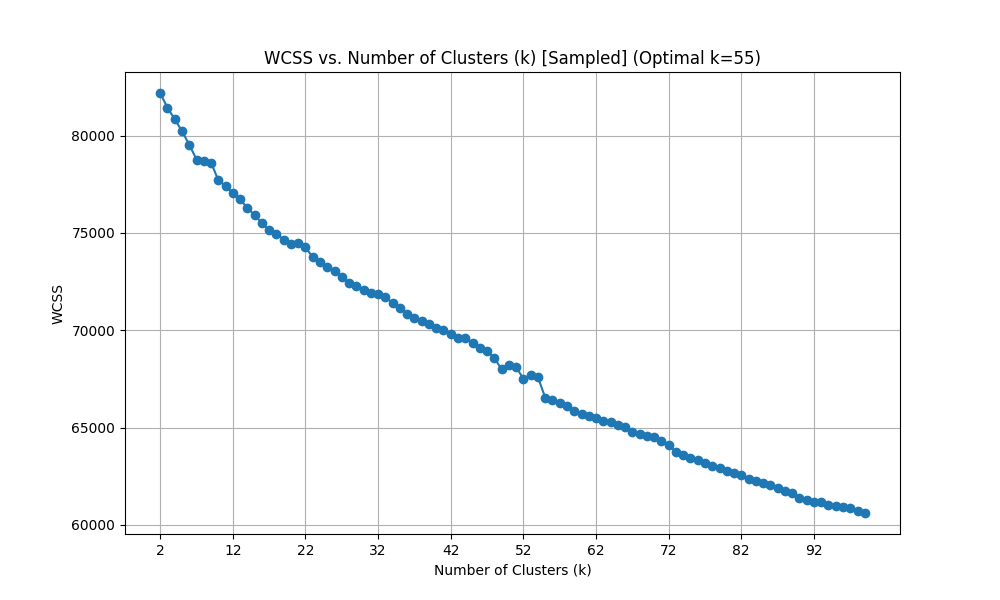

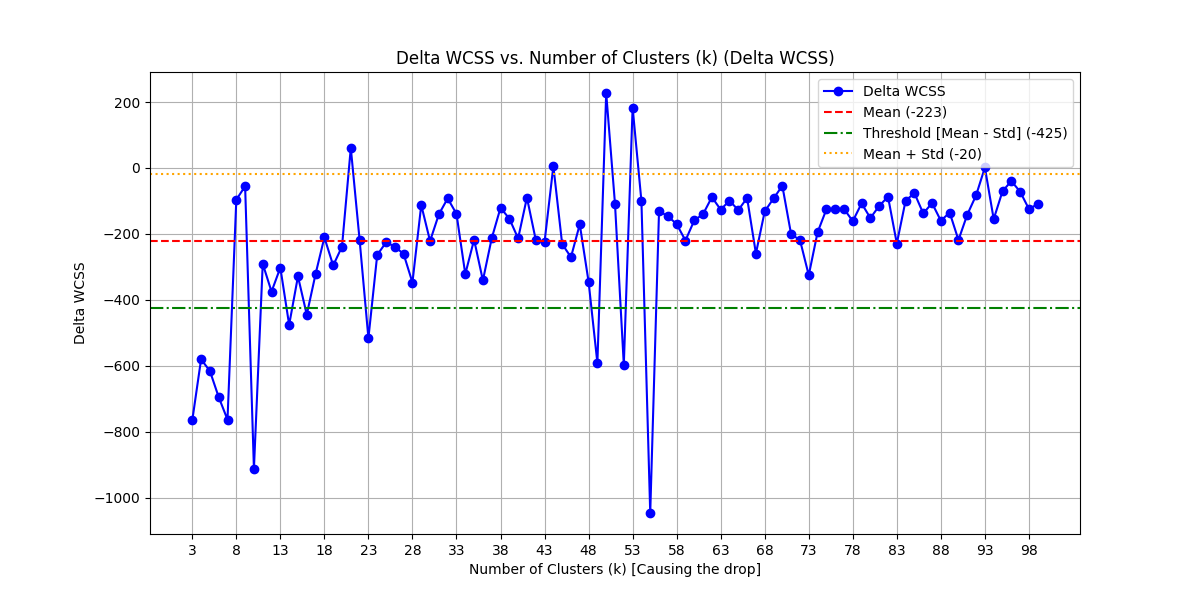


Loaded previously calculated optimal K: 55


In [65]:
wcss_dir = "clustering/kmeans/WCSS"
os.makedirs(wcss_dir, exist_ok=True)

# Search for any file ending in .png in the directory
wcss_pngs = glob.glob(os.path.join(wcss_dir, "*.png"))

optimal_k = 55 # FALLBACK 
optimal_k_file = os.path.join(wcss_dir, "optimal_k.txt")

if not wcss_pngs:
    # Run the heavy calculation
    calculated_k = calculate_and_graph_wcss(tfidf_matrix=tfidf_matrix)
    
    if calculated_k:
        optimal_k = calculated_k
        # Save this number to a text file so we remember it for the next run!
        with open(optimal_k_file, "w") as f:
            f.write(str(optimal_k))
else:
    print(f"WCSS graphs already exist in '{wcss_dir}'. Skipping heavy calculation.\n")
    
    # Display the found images directly in the Jupyter Notebook
    for img_path in wcss_pngs:
        display(Image(filename=img_path))
        
    # Try to load the previously saved optimal K
    if os.path.exists(optimal_k_file):
        with open(optimal_k_file, "r") as f:
            optimal_k = int(f.read().strip())
        print(f"\nLoaded previously calculated optimal K: {optimal_k}")
    else:
        print(f"\nNo saved K value found. Defaulting to K={optimal_k}")

##### Evaluating Variance Reductions (Delta WCSS)
To isolate the exact point of diminishing returns, we examined the Delta WCSS against the aforementioned threshold. While we observe profound initial drops in variance at early stages (e.g., $k=10$ and $k=23$), the graph displays continued, violent oscillation up until the 50-cluster mark.

Following the most unstable segment of the distribution, the data experiences its absolute largest variance reduction at exactly $k=55$, plunging to roughly $-1050$. Crucially, immediately following this final, massive separation, the volatility virtually disappears. From $k=56$ onward, the Delta WCSS rapidly flattens out, hovering consistently above the established threshold without ever crossing it again. By selecting $k=55$ as the optimal number of clusters, we capture the last substantial drop in variance, avoiding the plateau of diminishing returns that follows.







#### Executing KMeans
With the optimal number of clusters ($k=55$) identified, the actual clustering is executed using `scikit-learn`'s KMeans implementation. K-Means aims to divide the dataset into $k$ non-overlapping subsets by minimizing the within-cluster variance. The algorithm operates iteratively (via Lloyd's algorithm): it assigns each playlist vector to the nearest geometric center (centroid), and then updates that centroid to be the mathematical mean of all its assigned points, repeating this process until the centers stop moving.

To implement the model, we instantiate `sklearn.cluster.KMeans` with the following hyperparameters:
- **`n_clusters=55`**: The target number of distinct groups, derived from our Delta WCSS analysis. This ensures we capture the major structural separations in the corpus without overfitting.
- **`n_init=10`**: A well-known disadvantage of Lloyd’s heuristic algorithm is its sensitivity to initialization as it can easily get trapped in poor local optima. Setting this to 10 forces the algorithm to run 10 complete, independent times with different random starting centroids. The model ultimately keeps the run that achieves the absolute lowest inertia.
- **`max_iter=300`**: Allows each of the 10 runs up to 300 iterations to reach internal convergence. Given the high dimensionality and sparsity of our TF-IDF text space, ensuring sufficient iterations guarantees that the centroids have fully stabilized before termination.
- **`random_state=RANDOM_SEED`**: Fixes the underlying random number generator to ensure perfectly reproducible results across environments.

After fitting the model, a dictionary maps the resulting cluster labels back to the original DataFrame based on the expanded text features. 

In [66]:
from clustering.kmeans.kmeans_clustering import KMeansClustering

In [67]:
KMeans = KMeansClustering(k=55, max_iter=300, n_init=10, random_state=RANDOM_SEED)

k_means_55_col = getattr(KMeans, "cluster_col", None)
report_out = KMeans.report_dir

print(f"Checking for: '{k_means_55_col}' in columns: {df.columns.tolist()[:10]}...")
if k_means_55_col in df.columns:
    print(f"\n[SKIP] {KMeans.algo_name} already exists in column '{k_means_55_col}'.")
else:
    print(f"\n{'='*50}")
    print(f"Executing Pipeline for: {KMeans.algo_name}")
    print(f"{'='*50}")

    df, target_col = KMeans.run_pipeline(df, unique_texts, tfidf_matrix)
    KMeans.create_report()

    if target_col and target_col in df.columns:
        from preprocessing.preprocessor import FULLY_PROCESSED_PARQUET
        print(f"[INFO] Saving updated labels to {FULLY_PROCESSED_PARQUET}...")
        df.to_parquet(FULLY_PROCESSED_PARQUET, index=False)

Checking for: 'k-means_cluster_55' in columns: ['user_id', 'artistname', 'trackname', 'playlistname', 'homogenized_playlist', 'is_contextual', 'filtered_playlist', 'expanded_features', 'k-means_cluster_55', 'birch_cluster_55']...

[SKIP] KMeans already exists in column 'k-means_cluster_55'.


### Birch (Hierachical Clustering)
To address the potential limitations of K-Means’ rigid, global partitioning, we implemented BIRCH (Balanced Iterative
Reducing and Clustering using Hierarchies).

BIRCH operates in two distinct phases that structurally mirror the nested nature of music (e.g., sub-genres). 
Playlists are processed incrementally, constructing a specialized data structure called a Clustering Feature (CF) Tree. Data points are summarized into CFs which represent a tightly packed sphere of points. If a playlist vector falls within the radius of an existing sphere, it is absorbed into that sphere, if it doesn't, a new CF is created. This creates clusters, but not necessarily $k$. Therefore an agglomerative hierarchical clustering algorithm is run on the centroids marge the closest pairs until there are $k$ clusters.

K-Means is known to be
sensitive to noise, often letting outliers/noise pull centroids off center, as they’re forced to assign every point to a cluster. The bottom-up approach of BIRCH ensures that the final macro-clusters are built from pure semantic building blocks
rather than forced global averages. Furthermore, the final agglomerative merge allows for non-spherical clusters, unlike
k-means. By finding clusters from highly specific sub-contexts, BIRCH allows us to test if a hierarchical structural
definition better captures the semantic reality of human musical curation.

#### Executing Birch
To implement BIRCH we instantiate the `sklearn.cluster.Birch` model with three hyperparameters.
 - **`**k=55`**: The amount of desired clusters. Derived from WCSS, chosen such that we can compare results with K-means.
 - **`**Thereshold=0.9`**: Controls the maximum radius of a sub-cluster. As our TF-IDF matrix creates a high-dimensional sparse space, the points will naturally be far apart. A threshold of 0.9 aims to be forgiving enough to group slight varying text structures (e.g., "workout mix" and "gym playlist"), while still separating distinct broader contexts.
 - **`**Branching Factor=25`**: Defines the width limit of the tree. 25 was chosen as a moderates alternative to the default 50, which aims to mirror the deeply nested music taxonomy. 
We thereafter call the fit and predict methods, corresponding to the aforementioned process.
- **`random_state=RANDOM_SEED`**: Fixes the underlying random number generator to ensure perfectly reproducible results across environments.

In [68]:
from clustering.birch.birch_clustering import BirchClustering

In [69]:
# Initialize BirchClustering instance
Birch = BirchClustering(k=55, threshold=0.9, branching_factor=25, batch_size=1000)

birch_55_col = getattr(Birch, "cluster_col", None)
report_out = Birch.report_dir

print(f"Checking for: '{birch_55_col}' in columns: {df.columns.tolist()[:10]}...")
if birch_55_col in df.columns:
    print(f"\n[SKIP] {Birch.algo_name} already exists in column '{birch_55_col}'.")
else:
    print(f"\n{'='*50}")
    print(f"Executing Pipeline for: {Birch.algo_name}")
    print(f"{'='*50}")

    df, target_col = Birch.run_pipeline(df, unique_texts, tfidf_matrix)
    Birch.create_report()

    if target_col and target_col in df.columns:
        print(f"[INFO] Saving updated labels to {FULLY_PROCESSED_PARQUET}...")
        df.to_parquet(FULLY_PROCESSED_PARQUET, index=False)

Checking for: 'birch_cluster_55' in columns: ['user_id', 'artistname', 'trackname', 'playlistname', 'homogenized_playlist', 'is_contextual', 'filtered_playlist', 'expanded_features', 'k-means_cluster_55', 'birch_cluster_55']...

[SKIP] BIRCH already exists in column 'birch_cluster_55'.


### Evaluation
To validate whether our discovered clusters represent meaningful musical contexts, we implemented a recommendation
evaluation pipeline directly mirroring the methodology of Pichl et al. [CITE?]. Since we don’t have a ground truth, we
evaluate the clusters based on their utility in a Collaborative Filtering scenario.

To do this, we restrict the collaborative filtering within each cluster. The aim is hence to analyze wether the
boundaries make semantic sense. We simulate a recommendation scenario by splitting songs within a playlist into
test and training dictionaries. The algorithm is then tasked with predicting these missing tracks by utilizing similar
playlists within the target’s cluster. We quantify the relevance of each potential neighbor using Jaccard Similarity. Let
T represent the set of visible tracks in the target playlist, and N represent the set of tracks in a neighboring playlist. The similarity score is calculated as the intersection over the union:

$$J(T, N) = \frac{|T \cap N|}{|T \cup N|}$$

For each neighbor the algorithm isolates new tracks, where they are assigned a weight equal to the sum of Jaccard
similarities of the neighbors that provided it. These tracks are thereafter sorted in descending order and we evaluate
how many of the originally "masked" tracks appear at the very top of this ranked list using the $F_{0.1}$ metric. Ultimately,
a higher score proves that the clustering algorithm successfully grouped pure, cohesive musical contexts, allowing the
collaborative filter to draw from a highly relevant neighborhood.

The performance of the recommendation models is illustrated in the graph, which compares the $F_{0.1}$-measure (y-axis) against the recommendation density $p$ (x-axis), representing the fraction of the test set size used to generate recommendations. The "top-k" lines (Top-1, Top-5, Top-10) represent the average performance of clusters that were ranked in descending order based on their computed $F_{0.1}$ scores.


#### Evaluating K-Means

In [70]:
from evaluation.evaluator import eval

# Evaluate KMeans results and save the report (IF NOT DONE ALREADY)
k_means_report_out = KMeans.report_dir
if k_means_55_col in df.columns:
    # The evaluation has happened
    print(f"\n[SKIP] Evaluation for {KMeans.algo_name} already exists in column '{k_means_55_col}'.")
else:
    os.makedirs(k_means_report_out, exist_ok=True)
    eval_report_path = os.path.join(k_means_report_out, f"evaluation_metrics_{k_means_55_col}.txt")

    # Running evaluation and saving the report
    print(f"\n[INFO] Evaluating {KMeans.algo_name} results and saving report to '{eval_report_path}'...") 
    eval(df=df,
         cluster_col=k_means_55_col,
         unique_texts=unique_texts,
         tfidf_matrix=tfidf_matrix,
         sample_frac=0.1,
         output_dir=k_means_report_out)


[SKIP] Evaluation for KMeans already exists in column 'k-means_cluster_55'.


#### Evaluating BIRCH

In [71]:
from evaluation.evaluator import eval

# Evaluate BIRCH results and save the report (IF NOT DONE ALREADY)
birch_report_out = Birch.report_dir
if birch_55_col in df.columns:
    # The evaluation has happened
    print(f"\n[SKIP] Evaluation for {Birch.algo_name} already exists in column '{birch_55_col}'.")
else:
    os.makedirs(birch_report_out, exist_ok=True)
    eval_report_path = os.path.join(birch_report_out, f"evaluation_metrics_{birch_55_col}.txt")

    # Running evaluation and saving the report
    print(f"\n[INFO] Evaluating {Birch.algo_name} results and saving report to '{eval_report_path}'...") 
    eval(df=df,
         cluster_col=birch_55_col,
         unique_texts=unique_texts,
         tfidf_matrix=tfidf_matrix,
         sample_frac=0.1,
         output_dir=birch_report_out)


[SKIP] Evaluation for BIRCH already exists in column 'birch_cluster_55'.


#### Plotting the $F_{0.1}$ Results

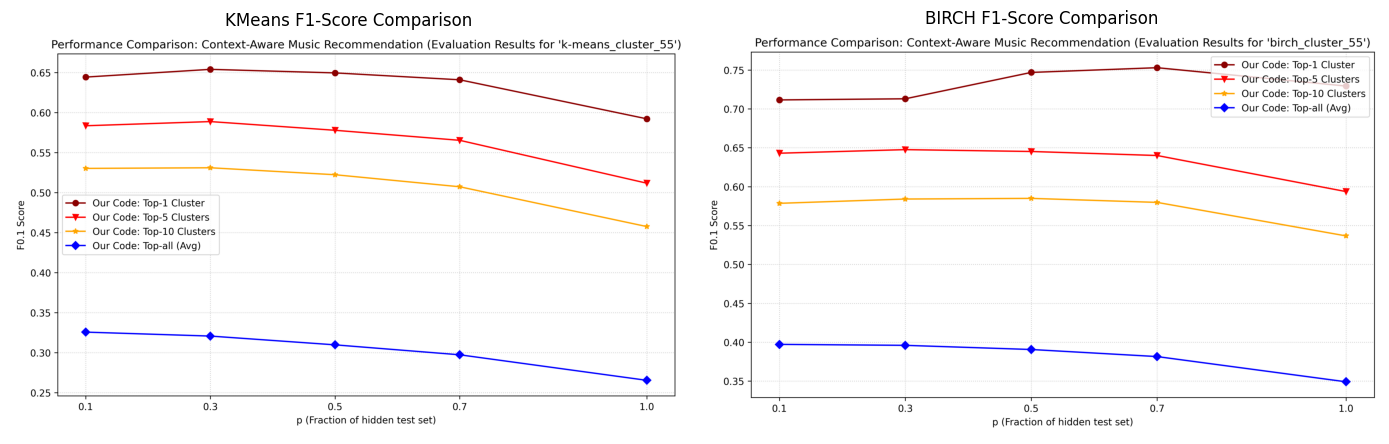

In [72]:
# Plotting the results side by side for comparison
k_means_55_path = os.path.join(k_means_report_out, "f01_comparison.png")
birch_path = os.path.join(birch_report_out, "f01_comparison.png")

# Plotting them side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(plt.imread(k_means_55_path))
axes[0].set_title(f"{KMeans.algo_name} F1-Score Comparison")
axes[0].axis('off')
axes[1].imshow(plt.imread(birch_path))
axes[1].set_title(f"{Birch.algo_name} F1-Score Comparison")
axes[1].axis('off')
plt.tight_layout()
plt.show()

#### Overall Predictive Trends
The results across both implementations exhibit an intuitive hierarchy: evaluating only the absolute highest-scoring cluster (Top-1) yields the highest predictive accuracy. As we average performance across wider brackets (Top-5, Top-10, and Top-all), the overall score predictably degrades as lower-signal clusters are introduced. Generally, increasing $p$ causes the score to decline as the system is forced to fill a larger quota with tracks of diminishing relevance. Both K-Means and BIRCH occasionally however show performance gains when moving from $p=0.1$ to $0.3$ and occasionally beyond. This suggests that a very small $p$ may be too restrictive; by $p=0.3$, the algorithm is allowed enough "guesses" to capture relevant tracks that were ranked highly but not first.


#### Comparison to the Original Findings
When comparing our findings to the baseline established by Pichl et al. [CITE], two major distinctions emerge. First, both of our models demonstrate a higher baseline of accuracy. Second, the original paper's results exhibit a significant drop in performance immediately after $p=0.6$, whereas out models maintain a more smooth gradual decay. We attribute the discrepancy to our enhanced preprocessing pipeline.
By applying more strict entity and stop word filtering prior to our TF-IDF vectorizations, we significantly increased the semantic signal-to-noise ratio.

#### K-Means vs. Birch
The empirical disparity between K-means (max $F_{0.1} \approx 0.65$) and BIRCH (max $F_{0.1} \approx 0.75$) validates our core hypothesis. K-means optimizes a global objective function that enforces a rigid, spherical cluster geometry. When applied to our high-dimensional sparse TF-IDF matrix, this representative-based approach is highly susceptible to noise, as outliers disproportionately distort the global centroids, diluting the intra cluster similarities. BIRCH on the other hand uses a structural paradigm that naturally quarantines semantic noise and topological outliers into isolated leaf ndes, preventing them from skewing the broader centroids. This results in the evaluation algorithm drawing from a search space of higher semantic purity. The results confirm that a hierarchical model is better suited to model the boundaries of human musical taxonomy.



### Subspace Clustering
Inspecting the cluster size distributions for both K-Means and BIRCH reveals a persistent 'gravity well': a single cluster containing a disproportionate percentage of the dataset.
While BIRCH is theoretically more robust to noise through its hierarchical micro-clustering, the persistence of this giant cluster suggests that a significant portion of user-generated playlists share a generic semantic overlap in the full 5,000-dimensional TF-IDF space. Although significant preprocessing has been implemented to reduce this effect, it indicates that the semantic signals defining distinct contexts are being drowned out by high-frequency, non-contextual terms. This finding provides the primary empirical justification for subspace clustering, as we hypothesize that these contexts can only be separated by projecting the data into lower-dimensional subspaces where these generic terms are ignored. 

**SUBSPACE CLUSTERING NOT IMPLEMENTED**

## 3. Module 2 — Graph-Based Analysis
**Initial task description (Module 2 perspective):**
Building upon our structural discoveries from Module 1, our second analysis phase shifts the focus from global geometric alignment to local topological structures. Evidence suggests that calculating classical distances across a sparse, high dimensional text space is inherently noisy, which is not ideal to capture the nuanced semantic boundaries. To address this limitation, we model the data as a graph, transforming textual similarities into a network topology.

We implemented two graph mining algorithms to identify these contextual boundaries. We selected Spectral Clustering and the Louvain method because they represent two fundamentally opposing topological paradigms: top-down global partitioning and bottom-up local agglomeration. While our overarching shift to a graph-based approach aims to structurally mitigate the spatial "gravity well" effect, the juxtaposition of these specific algorithms provides deeper behavioral insight. Specifically, it evaluates whether the human musical curation landscape is more accurately modeled as a globally partitioned space defined by distinct boundaries, or as a locally agglomerated space driven by internal cohesion.


### Preprocessing
The primary preprocessing step in this phase involves converting our global TF-IDF matrix into a local k-NN similarity graph. We chose this text-based graph conversion method over a behavior-based (such as a shared-track bipartite graph) for three methodological reasons: it preserves our core research question regarding the semantic value of playlist names, it ensures a controlled comparison against our baseline by keeping the input features constant, and it acts as a structural remedy to the "gravity well" effect observed part 1 by mathematically severing generic ties and isolating relevant local neighborhoods.

To do this, we calculate the Cosine Similarity using the values of the TF-IDF between each playlist. Thereafter we sparsify the values, converting all but the top 10 highest numbers for each row to 0. The result is a weighted adjacency matrix where each playlist is a node, and every non-zero number becomes an edge. We choose k to be 10 to ensure inclusivity while preventing massive node hubs, and we define a minimum threshold of 0.15 to ensure we don't force connections of low quality.

Crucially, this process provides new opportunities for structural analysis that traditional geometric clustering cannot offer. The new network representation allows us to model musical curation as interconnected communities, which establishes the ideal foundational topology for our graph mining methodologies, which identify natural boundaries based on network density rather than global spatial distance.

In [73]:
from graph.knn.knn_graph import KNNGraph

In [74]:
graph_builder = KNNGraph(k_neighbors=10, sim_threshold=0.15)
    
graph_config_name = f"k{graph_builder.k}_sim{graph_builder.sim_threshold}_N{len(unique_texts)}"

graph_save_dir = os.path.join("graph", "knn", "saved_graphs")
os.makedirs(graph_save_dir, exist_ok=True)

graph_save_path = os.path.join(graph_save_dir, f"knn_{graph_config_name}.pkl")

if os.path.exists(graph_save_path):
    print(f"\n[INFO] Loading previously built k-NN graph from {graph_save_path}...")
    with open(graph_save_path, "rb") as f:
        graph_builder.G = pickle.load(f)
else:
    print("\n[INFO] Building shared k-NN graph for graph-based clustering...")
    graph_builder.build_graph(tfidf_matrix, unique_texts)
    
    print(f"[INFO] Saving generated k-NN graph to {graph_save_path}...")
    with open(graph_save_path, "wb") as f:
        pickle.dump(graph_builder.G, f)


[INFO] Loading previously built k-NN graph from graph/knn/saved_graphs/knn_k10_sim0.15_N84696.pkl...


### Louvain Community Detection
The Louvain method is a heuristic bottom up approach designed to discover communities by Maximizing Modularity.
Modularity is a scalar value that quantifies the density of a random graph. The algorithm operates in a continuous 2
phase loop, phase 1 allowing nodes to iteratively jump to neighboring communities that yield the highest increase in
modularity, and phase 2 aggregating the communities into "super nodes". This continues until the global modularity can
no longer be improved. This allows the method to discover the optimal communities.
We specifically chose the Louvain method over Ravasz and link clustering as both run O($n^2$) complexity, as
opposed to Louvain’s O($m$).

#### Executing Louvain Community Detection - $k = 322$
We execute the Louvain algorithm using the python-louvain library, specifically invoking the best_partition() function on our interconnected network of playlists.

When invoking the algorithm, we pass our k-NN graph directly into the function without explicitly overriding the default hyperparameters. We designed our execution strategy around two default parameters:

- **weight='weight'**: Modularity works by evaluating edge densities. We explicitly stored our TF-IDF cosine similarities under the "weight" edge attribute during the k-NN graph construction and hence Louvain automatically detects and leverages this data. This  upgrades the algorithm from evaluating basic, binary network connections to evaluating the contextual equivalence between playlists.
- **resolution=1.0**: As we are basing our project on structure discovery, we define the default resolution, as this is where the modularity equation is balanced and where clusters are defined naturally based on density.

In [75]:
# Initialize Louvain Clustering instance, and load the graph from the shared builder
from graph.knn.louvain_clustering import LouvainClustering
Louvain = LouvainClustering(graph=graph_builder.G, graph_config_name=graph_config_name, random_state=RANDOM_SEED)

In [76]:
# Get the cluster_col name, which we use to accesss / save the data frame
louvain_col = getattr(Louvain, "cluster_col", None)
# Report output directory for Louvain
louvain_report_out = Louvain.report_dir

In [77]:
# Check if the Louvain column already exists to avoid redundant computation
if louvain_col in df.columns:
    print(f"\n[SKIP] {Louvain.algo_name} already exists in column '{louvain_col}'.")

# If the column doesn't exist, we run the full pipeline for Louvain clustering
else:
    print(f"\n{'='*50}")
    print(f"Executing Pipeline for: {Louvain.algo_name}")
    print(f"{'='*50}")

    # Pipeline execution
    df, target_col = Louvain.run_pipeline(df, unique_texts, tfidf_matrix)
    # Report creation
    Louvain.create_report()

    # If the pipeline produced a new target column, we save the updated dataframe with the new labels
    if target_col and target_col in df.columns:
        from preprocessing.preprocessor import FULLY_PROCESSED_PARQUET
        print(f"[INFO] Saving updated labels to {FULLY_PROCESSED_PARQUET}...")
        df.to_parquet(FULLY_PROCESSED_PARQUET, index=False)


[SKIP] Louvain already exists in column 'louvain_community_labels_42'.


### Spectral Clustering
Spectral Clustering is a deterministic partitioning technique rooted in linear algebra that identifies optimal global cuts.
It uses the Laplacian matrix to find eigenvectors/eigenvalues and uses them to project the complex topology into a
lower dimensional spectral space. Dense communities mathematically pull apart, and K-means can be applied to find k
distinct partitions.
We specifically chose Spectral Clustering as opposed to similar alternatives due to its performance on sparse
k-NN graphs, in which libraries like scikit-learn allows complexity of $O(km)$ (where $m$ is the number of edges.)

#### Executing Spectral Clustering
To execute the algorithm, we utilize the SpectralClustering implementation from the scikit-learn library. Spectral Clustering requires a mathematical representation of our interconnected network. We translate our networkx k-NN graph into a SciPy sparse adjacency matrix, explicitly ensuring that the algorithm inherits our TF-IDF cosine similarities by preserving the edge weight attributes.

We instantiate the model with the following hyperparameters:
- **n_clusters=???**: We match it with the final cluster value from Louvain, for a fair comparison.
- **affinity="precomputed"**: This parameter instructs the algorithm to bypass its internal similarity calculations and instead accept our spatial matrix. We chose this to ensure the model evaluates the network based on the TF-IDF cosine similarities we established during the k-NN graph construction.
- **eigen_solver="arpack"**: The ARPACK solver was explicitly chosen over standard solvers because it is mathematically much more stable when handling disjointed network topologies such as ours.
- **assign_labels="cluster_qr"**: We use QR decomposition for the final labeling step rather than the default k-means approach, as it provides a significantly faster and strictly deterministic result.

In [78]:
# Initialize Spectral Clustering instance, and load the graph from the shared builder
from graph.knn.spectral_clustering import SpectralGraphClustering
Spectral_322 = SpectralGraphClustering(graph=graph_builder.G, n_clusters=322, graph_config_name=graph_config_name)

In [79]:
# Get the cluster_col name, which we use to accesss / save the data frame
spectral_col_322 = getattr(Spectral_322, "cluster_col", None)
# Report output directory for Spectral
spectral_report_out_322 = Spectral_322.report_dir

In [80]:
# Check if the Spectral column already exists to avoid redundant computation
if spectral_col_322 in df.columns:
    print(f"\n[SKIP] {Spectral_322.algo_name} already exists in column '{spectral_col_322}'.")

# If the column doesn't exist, we run the full pipeline for Spectral clustering
else:
    print(f"\n{'='*50}")
    print(f"Executing Pipeline for: {Spectral_322.algo_name}")
    print(f"{'='*50}")

    # Pipeline execution
    df, target_col = Spectral_322.run_pipeline(df, unique_texts, tfidf_matrix)
    # Report creation
    Spectral_322.create_report()

    # If the pipeline produced a new target column, we save the updated dataframe with the new labels
    if target_col and target_col in df.columns:
        from preprocessing.preprocessor import FULLY_PROCESSED_PARQUET
        print(f"[INFO] Saving updated labels to {FULLY_PROCESSED_PARQUET}...")
        df.to_parquet(FULLY_PROCESSED_PARQUET, index=False)


[SKIP] Spectral already exists in column 'spectral_cluster_322'.


### Evaluation

#### Spectral Clustering Evaluation

In [81]:
# Safety Net
if spectral_col_322 in df.columns:
    os.makedirs(spectral_report_out_322, exist_ok=True)
    spectral_report_path = os.path.join(spectral_report_out_322, f"evaluation_metrics_{spectral_col_322}.txt")
    # Skip Logic
    if os.path.exists(spectral_report_path):
        print(f"\n[SKIP] Evaluation for {Spectral_322.algo_name} already exists at '{spectral_report_path}'.")
    else:
        print(f"\n[INFO] Column '{spectral_col_322}' exists but no evaluation report found. Running eval for {Spectral_322.algo_name}...")
        eval(df=df,
             cluster_col=spectral_col_322,
             unique_texts=unique_texts,
             tfidf_matrix=tfidf_matrix,
             sample_frac=0.1,
             output_dir=spectral_report_out_322)


[SKIP] Evaluation for Spectral already exists at 'clustering/reports/Spectral/k10_sim0.15_N84696_k322/evaluation_metrics_spectral_cluster_322.txt'.


#### Louvain Community Detection Evaluation

In [82]:
# Safety Net
if louvain_col in df.columns:
    os.makedirs(louvain_report_out, exist_ok=True)
    louvain_report_path = os.path.join(louvain_report_out, f"evaluation_metrics_{louvain_col}.txt")
    # Skip Logic
    if os.path.exists(louvain_report_path):
        print(f"\n[SKIP] Evaluation for {Louvain.algo_name} already exists at '{louvain_report_path}'.")
    else:
        print(f"\n[INFO] Column '{louvain_col}' exists but no evaluation report found. Running eval for {Louvain.algo_name}...")
        eval(df=df,
             cluster_col=louvain_col,
             unique_texts=unique_texts,
             tfidf_matrix=tfidf_matrix,
             sample_frac=0.1,
             output_dir=louvain_report_out)


[SKIP] Evaluation for Louvain already exists at 'clustering/reports/Louvain/k10_sim0.15_N84696/evaluation_metrics_louvain_community_labels_42.txt'.


##### Plotting $F_{0.1}$-scores

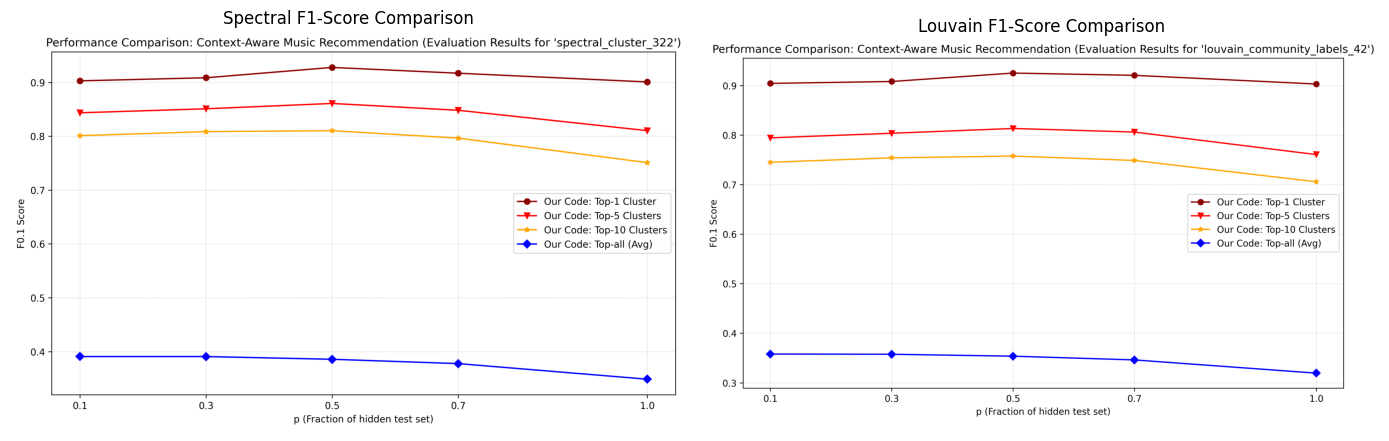

In [83]:
# Plotting the results side by side for comparison
spectral_322_dist_path_fscore = os.path.join(spectral_report_out_322, "f01_comparison.png")
louvain_dist_path_fscore = os.path.join(louvain_report_out, "f01_comparison.png")

# Plotting them side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(plt.imread(spectral_322_dist_path_fscore))
axes[0].set_title(f"{Spectral_322.algo_name} F1-Score Comparison")
axes[0].axis('off')
axes[1].imshow(plt.imread(louvain_dist_path_fscore))
axes[1].set_title(f"{Louvain.algo_name} F1-Score Comparison")
axes[1].axis('off')
plt.tight_layout()
plt.show()

We are comparing both models at a fixed parameter of $k = 322$, which provides a controlled baseline, Spectral Clustering deomnstrates a structural advantage, particularly in the broader recommendation brackets (maintaining higher Top-5 and Top-10 scores than Louvain). However, forcing Spectral Clustering to match the dynamic community count discovered by Louvain introduces a significant methological constraint. Louvain optimizes for network modularity and density, naturally settling on 322 communities as its ideal structural representation of the data. Spectral Clustering relies on identifying optimal mathematical cuts within the graph's eigenspace. 

By artificially restricting Spectral to 322 partitions, we are likely handicapping its underlying logic and forcing distinct semantic micro-communities to remain merged. This leads us to hypothesize that 322 is not the optimal parameter for Spectral in this high-dimensional space. To evaluate its true predicitve potential, we must decouple its parameterization from Louvain's density-based results, mathematically determine Spectral's own optimal number of clusters, and analyze its unconstrained performance. 

#### The Search of the Optimal K (Silhouettte and Eigengap Heuristics)
In tuning Spectral Clustering, we have had to pick $k$ as a hyperparameter, this $k$ has not been arbitrarily chosen. We started by calculating the *silhouette/eigengap* score for every $k$ up to 322, which was the optimal $k$ found by Louvain, seeing as the score kept increasing the interval was brought up to 1500, with sampling at every 50th $k$, the optimal $k$ was found at 700. To more accurately pin-point the exact $k$ we calculated silhouette scores of surrounding $k$s (675-725) finding $k = 720$ to be optimal. 

While we previously utilized a **Delta WCSS** threshold to determine $k=55$ for representative-based models, graph-based models requires a different form of validation in choosing the optimal hyperparameter $k$. 

- Eigengap Heuristic: We analyze the eigenvalues $\lambda$ of the graph Laplacian to find the largest difference between consecutive values, defined as $\delta_k = \lambda_{k+1} - \lambda_k$. A maximized gap indicates the number of stable, natural communities within the network density. 

- Average Silhouette Coefficient: Because spectral clustering projects the sparse TF-IDF data into a new, low-dimensional coordinate system, we use the silhouette coefficient to evaluate the quality of the resulting clusters within the **spectral embedding space**. 

- Davies-Bouldin Index (DBI): To provide a final check on the 'efficiency' of our high-granularity partition, we utilize the DBI. This metric identifies the average similarity between each cluster $i$ and its most similar neighbor $j$, where $s$ is the cluster diameter and $d_{ij}$ is the distance between centroids:

$$DBI = \frac{1}{k}\sum_{i=1}^kmax_{j \neq i}(\frac{s_i+s_j}{d_{ij}})$$

For any individual playlist $i$, the silhouette scores $s(i)$ is calculated by compaing its average distance to other points in the same cluster, i.e. its cohesion $a(i)$ against its average distance to points in the nearest neighboring cluster, i.e. its separation $b(i)$:

$$s(i) = \frac{b(i) - a(i)}{max(a(i), b(i))}$$

The means of these individual scores across the entire contextual dataset is used in guiding the selection of $k$ because of these following properties:
- A high average silhouette scores (approaching 1) indicated that the spectral transformation has successfully mapped the complex, arbitrary shapes of user-generated musical contexts into well-separated, compact clusters in the eigenvector space. 
- While the eigengap heuristic identifies candidate values for $k$ based on the graph's connectivity, the silhouette coefficient provides a geometric 'sanity check' to ensure these partitions are cohesive. 
- Since human musical curation is often nested or high-dimensional, scores near 0 alert us to overlapping contexts where $k$ may be too high, preventing the 'gravity well' effect previously observed in the K-Means implementation

By calculating this metric within the spectral embedding space, we can verify if the graph-based network representation offers a higher 'semantic purity' than our previous representative-based baseline.

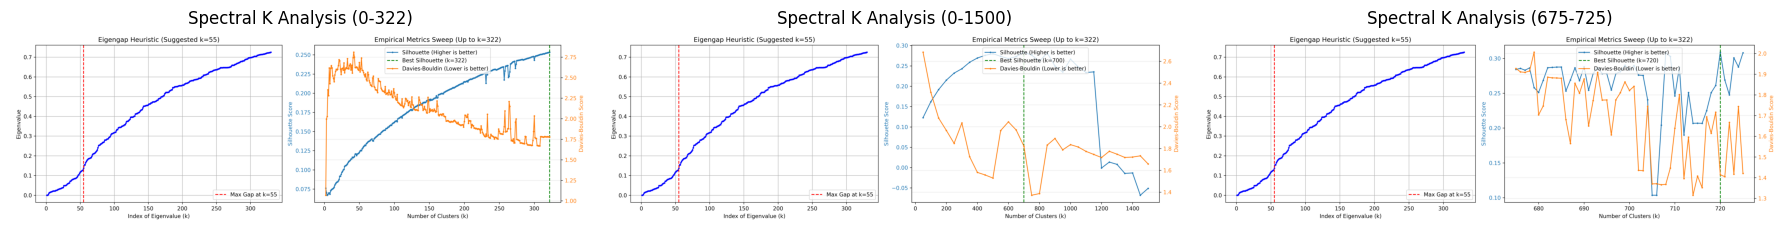

In [84]:
# Displaying of the silhouette scores, for different k values
path_img_1 = "scripts/data/spectral_k_analysis_spotify_0_322.png"
path_img_2 = "scripts/data/spectral_k_analysis_spotify_0_1500.png"
path_img_3 = "scripts/data/spectral_k_analysis_spotify_OPT720.png"

# 1x3 subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(plt.imread(path_img_1))
axes[0].set_title("Spectral K Analysis (0-322)")
axes[0].axis('off')
axes[1].imshow(plt.imread(path_img_2))
axes[1].set_title("Spectral K Analysis (0-1500)")
axes[1].axis('off')
axes[2].imshow(plt.imread(path_img_3))
axes[2].set_title("Spectral K Analysis (675-725)")
axes[2].axis('off')
plt.tight_layout()
plt.show()

#### Executing Spectral Clustering - $k = 720$

In [85]:
# Initialize Spectral Clustering instance, and load the graph from the shared builder
from graph.knn.spectral_clustering import SpectralGraphClustering
Spectral = SpectralGraphClustering(graph=graph_builder.G, n_clusters=720, graph_config_name=graph_config_name)

In [86]:
# Get the cluster_col name, which we use to accesss / save the data frame
spectral_col = getattr(Spectral, "cluster_col", None)
# Report output directory for Spectral
spectral_report_out = Spectral.report_dir

In [87]:
# Check if the Spectral column already exists to avoid redundant computation
if spectral_col in df.columns:
    print(f"\n[SKIP] {Spectral.algo_name} already exists in column '{spectral_col}'.")

# If the column doesn't exist, we run the full pipeline for Spectral clustering
else:
    print(f"\n{'='*50}")
    print(f"Executing Pipeline for: {Spectral.algo_name}")
    print(f"{'='*50}")

    # Pipeline execution
    df, target_col = Spectral.run_pipeline(df, unique_texts, tfidf_matrix)
    # Report creation
    Spectral.create_report()

    # If the pipeline produced a new target column, we save the updated dataframe with the new labels
    if target_col and target_col in df.columns:
        from preprocessing.preprocessor import FULLY_PROCESSED_PARQUET
        print(f"[INFO] Saving updated labels to {FULLY_PROCESSED_PARQUET}...")
        df.to_parquet(FULLY_PROCESSED_PARQUET, index=False)


[SKIP] Spectral already exists in column 'spectral_cluster_720'.


### Evaluation

#### Spectral Clustering Evaluation

In [88]:
# Safety Net
if spectral_col in df.columns:
    os.makedirs(spectral_report_out, exist_ok=True)
    spectral_report_path = os.path.join(spectral_report_out, f"evaluation_metrics_{spectral_col}.txt")
    # Skip Logic
    if os.path.exists(spectral_report_path):
        print(f"\n[SKIP] Evaluation for {Spectral.algo_name} already exists at '{spectral_report_path}'.")
    else:
        print(f"\n[INFO] Column '{spectral_col}' exists but no evaluation report found. Running eval for {Spectral.algo_name}...")
        eval(df=df,
             cluster_col=spectral_col,
             unique_texts=unique_texts,
             tfidf_matrix=tfidf_matrix,
             sample_frac=0.1,
             output_dir=spectral_report_out)


[SKIP] Evaluation for Spectral already exists at 'clustering/reports/Spectral/k10_sim0.15_N84696_k720/evaluation_metrics_spectral_cluster_720.txt'.


#### Spectral vs. Louvain


[INFO] Displaying evaluation comparison graphs for Spectral and Louvain...


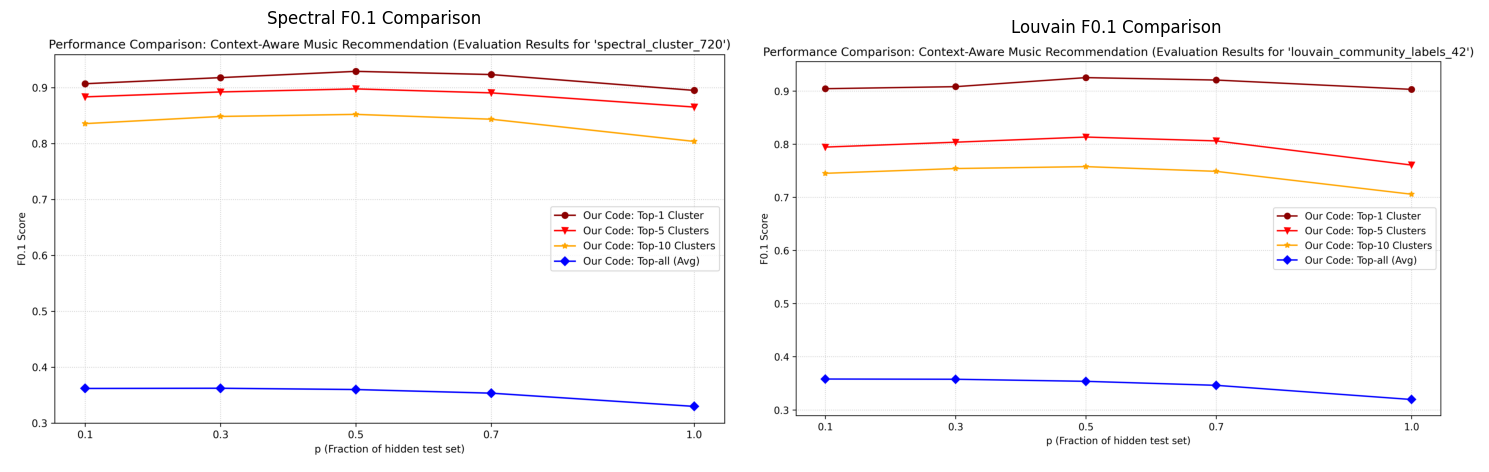

In [89]:
# Printing the two graphs side by side for comparison
if os.path.exists(spectral_report_path) and os.path.exists(louvain_report_path):
    print("\n[INFO] Displaying evaluation comparison graphs for Spectral and Louvain...")
    
    spectral_f01 = os.path.join(spectral_report_out, "f01_comparison.png")
    louvain_f01 = os.path.join(louvain_report_out, "f01_comparison.png")
    
    if os.path.exists(spectral_f01) and os.path.exists(louvain_f01):
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        axes[0].imshow(plt.imread(spectral_f01))
        axes[0].set_title(f"{Spectral.algo_name} F0.1 Comparison")
        axes[0].axis('off')
        
        axes[1].imshow(plt.imread(louvain_f01))
        axes[1].set_title(f"{Louvain.algo_name} F0.1 Comparison")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("[WARNING] One or both F0.1 comparison graphs are missing. Cannot display side by side.")

The evaluation results for our graph-based algorithms, Spectral Clustering and Louvain Community Detection, demonstrate a drastic improvement over the geometric approached applied in Module 1. Both graph-based methods achieved exceptional predictive performance, with Top-1 Cluster $F_{0.1}$ scores peaking around 0.9 to 0.92 across most test fractions. This is a great improvement compared to the maximum scores of roughly 0.69 for K-means and 0.78 for BIRCH observed previously. 

Louvain relies on greedy local heuristics to iteratively merge nodes that provide a gain in modularity. This
may perhaps constrain its semantic boundary precision due to two main factors. Firstly, its greedy nature makes it
susceptible to converging on local optima, as it only takes steps to improve modularity. Furthermore, it suffers from
a resolution limit, as its objective function evaluates local density against the total edge count (which in our case is
very high), where small communities may be erroneously merged to maximize the global score. On the other hand,
spectral clustering evaluates the structural flow of the entire network simultaneously, hence not being affected by these
limitations.

### How was feedback from Checkpoint 1 adressed?
 - Refined preprocessing descriptions
 - Divided feature and preprocessing sections
 - Show direct comparison and evaluation between algorithms

## 4. Module 3 — Pattern / Text Mining

In [90]:
# Pattern mining implementation
patterns = None

## 5. Final Synthesis and Reflection

- Key insights:
- Limitations:
- Revisions after feedback:


## Declaration of use of GAI tools
We have used the following generative artificial intelligence (GAI) to complete this project:
- Gemini 3.1 pro

We used GAI tools in the following way:
- Support with python syntax, comments and debugging.
- Assisted in refining text for conciseness and clarity.